In [5]:
#import packages
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn import datasets, image
from nilearn.connectome import ConnectivityMeasure
from nilearn.maskers import NiftiLabelsMasker
from nilearn.glm.first_level import FirstLevelModel

In [4]:
import numpy as np
import pandas as pd

# ───────────────
# Task Parameters
# ───────────────
TR         = 0.72
SYNC_SHIFT = 36.657   # from Sync.txt
WINDOW_SIZE = 35
STEP_SIZE   = 4
ORIGINAL_T  = 253     # From ts_resid.shape[0]

# ───────────────
# Raw block data (from EVs)
# Format: (label, onset, duration)
# ───────────────
raw_blocks = [
    ("loss",  8.063, 28.0),
    ("win",  51.951, 28.0),
    ("loss", 95.840, 28.0),
    ("win", 139.742, 28.0),
]

# ───────────────
# 1. Apply Sync shift to compute block TR range
# ───────────────
events = []
for label, onset, duration in raw_blocks:
    shifted_onset = onset - SYNC_SHIFT
    if shifted_onset < 0:
        continue
    start_tr = int(np.floor(shifted_onset / TR))
    end_tr   = int(np.ceil((shifted_onset + duration) / TR)) - 1
    events.append({
        "trial_type": label,
        "onset_sec":  shifted_onset,
        "duration_s": duration,
        "start_tr":   start_tr,
        "end_tr":     end_tr
    })

ev_df = pd.DataFrame(events)
print("\n=== BLOCKS AFTER SYNC SHIFT ===")
print(ev_df[["trial_type", "start_tr", "end_tr"]].to_string(index=False))

# ───────────────
# 2. Sliding Window Labeling (based on full ts_resid of length 253)
# ───────────────
T = ORIGINAL_T
n_windows = (T - WINDOW_SIZE) // STEP_SIZE + 1

window_labels = []
for t in range(n_windows):
    center_tr = t * STEP_SIZE + (WINDOW_SIZE // 2)
    hit = ev_df[(ev_df["start_tr"] <= center_tr) & (ev_df["end_tr"] >= center_tr)]
    window_labels.append(hit.iloc[0]["trial_type"] if not hit.empty else "no_event")

win_df = pd.DataFrame({
    "window_index": np.arange(n_windows),
    "center_tr":    np.arange(n_windows) * STEP_SIZE + (WINDOW_SIZE // 2),
    "block_label":  window_labels
})

print("\n=== WINDOW LABELS ===")
print(win_df.to_string(index=False))



=== BLOCKS AFTER SYNC SHIFT ===
trial_type  start_tr  end_tr
       win        21      60
      loss        82     121
       win       143     182

=== WINDOW LABELS ===
 window_index  center_tr block_label
            0         17    no_event
            1         21         win
            2         25         win
            3         29         win
            4         33         win
            5         37         win
            6         41         win
            7         45         win
            8         49         win
            9         53         win
           10         57         win
           11         61    no_event
           12         65    no_event
           13         69    no_event
           14         73    no_event
           15         77    no_event
           16         81    no_event
           17         85        loss
           18         89        loss
           19         93        loss
           20         97        loss
           21 

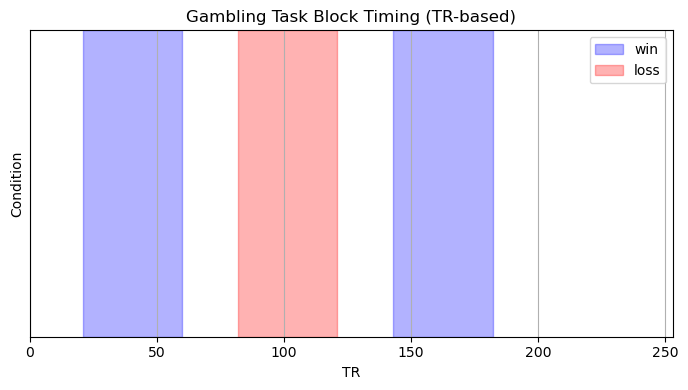

In [ ]:
import matplotlib.pyplot as plt

# Task parameters
TR = 0.72
SYNC_TIME = 36.657  # from Sync.txt

# Raw onset/duration from EVs
raw_blocks = [
    ("loss", 8.063, 28.0),
    ("win", 51.951, 28.0),
    ("loss", 95.840, 28.0),
    ("win", 139.742, 28.0),
]

# Convert to TR-based onsets (after sync correction)
corrected_blocks = []
for label, onset, duration in raw_blocks:
    shifted_sec = onset - SYNC_TIME
    if shifted_sec < 0:
        continue
    start_tr = int(shifted_sec // TR)
    end_tr   = int((shifted_sec + duration) // TR)
    corrected_blocks.append((label, start_tr, end_tr))

# Plot
plt.figure(figsize=(7, 4))
for label, start_tr, end_tr in corrected_blocks:
    color = 'red' if label == 'loss' else 'blue'
    alpha = 0.3
    label_name = label if label not in plt.gca().get_legend_handles_labels()[1] else None
    plt.axvspan(start_tr, end_tr, color=color, alpha=alpha, label=label_name)
w
plt.xlabel("TR")
plt.ylabel("Condition")
plt.title("Gambling Task Block Timing (TR-based)")
plt.xlim(0, 253)  # full run duration
plt.yticks([])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
BASE_DIR     = Path("C:/Users/JINHWA/Projects/BrainNetworkTDA/Dataset")
SUBJECT      = 100206
TASK         = "EMOTION"    # 또는 "EMOTION"
PHASE        = "LR"          # "LR" 또는 "RL"
WINDOW_SIZE  = 35            # TR 단위
STEP_SIZE    = 4             # TR 단위

In [7]:
aal = datasets.fetch_atlas_aal()
aal_img    = aal.maps    # AAL atlas NIfTI 경로
aal_labels = aal.labels  # ROI 이름 리스트

[get_dataset_dir] Dataset found in C:\Users\JINHWA\nilearn_data\aal_SPM12


In [8]:
masker    = NiftiLabelsMasker(
    labels_img       = aal_img,
    standardize      = "zscore_sample",
    detrend          = True,
    low_pass         = None,
    high_pass        = None,
    t_r              = 0.72,
    resampling_target = "data"
)

In [9]:
def make_paths(subject, task, phase="LR"):
    img_path = BASE_DIR / f"{subject:06d}/MNINonLinear/Results/tfMRI_{task}_{phase}/tfMRI_{task}_{phase}.nii.gz"
    ev_dir   = img_path.parent / "EVs"
    return img_path, ev_dir

In [10]:
def get_residual(img_path: Path, ev_dir: Path):
    """
    EVs 폴더 내의 *.txt 파일들을 건너뛰기 로직과 함께 읽어서
    onset/duration 정보를 모은 뒤, FirstLevelModel로 GLM을 수행한 후
    residual 4D 이미지를 반환합니다.
    """
    events = []

    for ev_file in sorted(ev_dir.glob("*.txt")):
        # 1) 순수히 숫자가 아닌 파일은 건너뛰기
        try:
            data = np.loadtxt(ev_file)
        except Exception:
            continue

        # 2) 빈 파일 혹은 숫자가 0개라면 건너뜀
        if data.size == 0:
            continue

        # 3) 1차원 배열(단일 행)인 경우, 열 개수 확인
        if data.ndim == 1:
            if data.shape[0] < 2:
                # onset/duration 정보를 담기 어렵다면 건너뜀
                continue
            data = data.reshape(1, -1)

        # 4) 2차원 배열(여러 행)인 경우, 열 개수가 2 또는 3인지 확인
        if data.ndim == 2:
            n_cols = data.shape[1]
            if n_cols not in (2, 3):
                continue
        else:
            # ndim이 0 또는 3 이상이면 건너뜀
            continue

        # 5) 최종적으로 data가 (N_events, 2) 혹은 (N_events, 3) 모양으로 보장됨
        if data.shape[1] == 3:
            onset_arr, duration_arr, _ = data.T
        else:  # data.shape[1] == 2
            onset_arr, duration_arr = data.T

        for o, d in zip(onset_arr, duration_arr):
            events.append({
                "onset":      float(o),
                "duration":   float(d),
                "trial_type": ev_file.stem
            })

    # 만약 events 리스트가 비어 있으면 None 반환
    if not events:
        return None

    # 이벤트가 모였다면 DataFrame으로 정리하고 GLM → residual 반환
    events_df = pd.DataFrame(events, columns=["onset", "duration", "trial_type"])
    fmri_img  = image.load_img(str(img_path))
    model     = FirstLevelModel(
        t_r              = 0.72,
        drift_model      = "polynomial",
        standardize      = False,
        minimize_memory  = False
    ).fit(fmri_img, events=events_df)

    return model.residuals[0]  # list이므로 첫 번째 residual 4D 이미지 반환


In [11]:
def sliding_window_dist(ts: np.ndarray, win: int, step: int) -> np.ndarray:
    """
    ts: (T, P) shaped array, T = time points, P = number of ROIs
    win: window length in TRs
    step: sliding step in TRs

    반환값: (n_windows, P, P) shaped array of 1 - |correlation| distance matrices
    """
    connectivity = ConnectivityMeasure(kind="correlation")
    T, P        = ts.shape
    n_windows   = (T - win) // step + 1
    out         = np.zeros((n_windows, P, P), dtype=np.float32)

    for idx, start in enumerate(range(0, T - win + 1, step)):
        segment      = ts[start : start + win]
        corr_matrix  = connectivity.fit_transform([segment])[0]
        dist_matrix  = 1.0 - np.abs(corr_matrix)
        out[idx]     = dist_matrix

    return out

In [12]:
OUT_DIR = Path("C:/Users/JINHWA/Projects/BrainNetworkTDA/Usedata/tfMRI_ts")
OUT_DIR.mkdir(exist_ok=True)

In [13]:
img_path, ev_dir = make_paths(SUBJECT, TASK, PHASE)
print(f"Loading {TASK} {PHASE} run from: {img_path}")

Loading GAMBLING LR run from: C:\Users\JINHWA\Projects\BrainNetworkTDA\Dataset\100206\MNINonLinear\Results\tfMRI_GAMBLING_LR\tfMRI_GAMBLING_LR.nii.gz


In [14]:
resid_img = get_residual(img_path, ev_dir)
if resid_img is None:
    raise RuntimeError(f"No usable EV files found for {TASK} {PHASE} run.")

c:\Users\JINHWA\miniconda3\envs\tda\Lib\site-packages\nilearn\glm\first_level\first_level.py:585: UserWarning: Mean values of 0 observed. The data have probably been centered.Scaling might not work as expected
  Y, _ = mean_scaling(Y, self.signal_scaling)


In [15]:
ts_resid = masker.fit_transform(resid_img)   # shape = (T, n_rois)
T, n_rois = ts_resid.shape
print(f"Extracted time-series shape: {ts_resid.shape}")

Extracted time-series shape: (253, 116)


In [16]:
dist_tensor = sliding_window_dist(ts_resid, WINDOW_SIZE, STEP_SIZE)
print(f"Distance tensor shape: {dist_tensor.shape}")

Distance tensor shape: (55, 116, 116)


In [17]:
out_path = OUT_DIR / f"{SUBJECT}_{TASK}_{PHASE}_AAL_resid_abs_dist.npy"
np.save(out_path, dist_tensor)
print(f"Saved → {out_path}")

Saved → C:\Users\JINHWA\Projects\BrainNetworkTDA\Usedata\tfMRI_ts\100206_GAMBLING_LR_AAL_resid_abs_dist.npy


In [18]:
OUT_DIR = Path(f"C:/Users/JINHWA/Projects/BrainNetworkTDA/Usedata/tfMRI_ts/{SUBJECT:06d}_gambling_dist")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [19]:
for i, mat in enumerate(dist_tensor):
    # 파일명 예시: rs100206_dist_matrix_000.txt, rs100206_dist_matrix_001.txt, ...
    file_path = OUT_DIR / f"gambling{SUBJECT}_dist_matrix_{i:03d}.txt"
    np.savetxt(file_path, mat, fmt='%.6f')
    # (원하는 경우, delimiter='\t' 등을 추가할 수 있습니다)
    # 예: np.savetxt(file_path, mat, fmt='%.6f', delimiter='\t')
    #print(f"Saved → {file_path}")

In [20]:
# Load the .txt file
txtfile = f'C:/Users/JINHWA/Projects/BrainNetworkTDA/Usedata/tfMRI_ts/100206_gambling_dist/gambling{SUBJECT:06d}_dist_matrix_000.txt'
data = np.loadtxt(txtfile)

# Sanity checks
print("=== TXT File Sanity Check ===")
print(f"Shape                : {data.shape}")  # Expecting (116, 116)
print(f"Number of entries    : {data.size}")
print(f"Expected entries     : 116 * 116 = {116 * 116}")
print(f"Min value            : {np.min(data):.4f}")
print(f"Max value            : {np.max(data):.4f}")
print(f"Any NaNs             : {np.isnan(data).any()}") # False: All values are real numbers
print(f"Any Infs             : {np.isinf(data).any()}") # False: All values are finite and valid

=== TXT File Sanity Check ===
Shape                : (116, 116)
Number of entries    : 13456
Expected entries     : 116 * 116 = 13456
Min value            : 0.0000
Max value            : 0.9999
Any NaNs             : False
Any Infs             : False


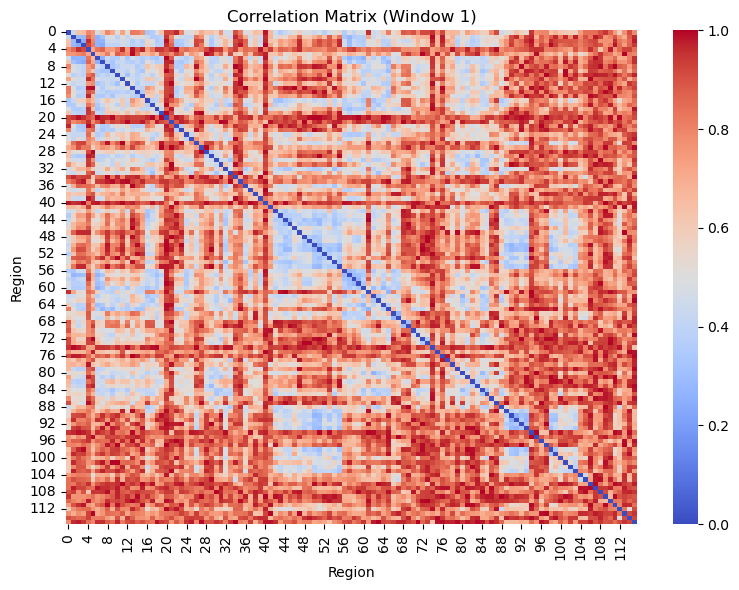

In [21]:
# === Plot sample heatmap ===
plt.figure(figsize=(8, 6))
sns.heatmap(dist_tensor[0], cmap='coolwarm', vmin=0, vmax=1)
plt.title("Correlation Matrix (Window 1)")
plt.xlabel("Region")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

In [22]:
import numpy as np
import pandas as pd
from pathlib import Path

# 사용자 설정
BASE_DIR    = Path("C:/Users/JINHWA/Projects/BrainNetworkTDA/Dataset")
SUBJECT     = 100206
TASK        = "GAMBLING"
PHASE       = "LR"
TR          = 0.72

ev_dir = BASE_DIR / f"{SUBJECT:06d}/MNINonLinear/Results/tfMRI_{TASK}_{PHASE}/EVs"
print("EV 폴더 경로:", ev_dir)

# EV 파일에서 onset/duration 읽기 (IndexError 방지 로직 적용)
all_events = []
for ev_file in sorted(ev_dir.glob("*.txt")):
    try:
        data = np.loadtxt(ev_file)
    except Exception:
        continue
    # data가 스칼라(숫자 하나)인 경우나 빈 경우 건너뛴다
    if data.ndim == 0 or data.size == 0:
        continue

    # 1차원 배열(한 줄)일 때
    if data.ndim == 1:
        if data.shape[0] == 3:
            onset_arr    = np.array([data[0]])
            duration_arr = np.array([data[1]])
        elif data.shape[0] == 2:
            onset_arr    = np.array([data[0]])
            duration_arr = np.array([data[1]])
        else:
            continue

    # 2차원 배열(여러 줄)일 때
    elif data.ndim == 2:
        n_cols = data.shape[1]
        if n_cols == 3:
            onset_arr, duration_arr, _ = data.T
        elif n_cols == 2:
            onset_arr, duration_arr = data.T
        else:
            continue

    else:
        # ndim이 0, 3 이상인 경우 모두 건너뛴다
        continue

    for o, d in zip(onset_arr, duration_arr):
        all_events.append({
            "trial_type": ev_file.stem,
            "onset_sec":  float(o),
            "duration_s": float(d)
        })

if not all_events:
    raise RuntimeError("읽을 수 있는 EV 이벤트가 없습니다.")

ev_df = pd.DataFrame(all_events, columns=["trial_type","onset_sec","duration_s"])
ev_df = ev_df.sort_values(by="onset_sec").reset_index(drop=True)

# TR 단위 변환
ev_df["start_tr"] = np.floor(ev_df["onset_sec"] / TR).astype(int)
ev_df["end_tr"]   = np.ceil((ev_df["onset_sec"] + ev_df["duration_s"]) / TR).astype(int) - 1

print("\n===== EV 이벤트 (TR 단위) =====")
print(ev_df[["trial_type","start_tr","end_tr"]].to_string(index=False))


EV 폴더 경로: C:\Users\JINHWA\Projects\BrainNetworkTDA\Dataset\100206\MNINonLinear\Results\tfMRI_GAMBLING_LR\EVs

===== EV 이벤트 (TR 단위) =====
trial_type  start_tr  end_tr
      loss        11      50
loss_event        11      16
loss_event        16      21
 win_event        21      26
loss_event        26      31
 win_event        31      36
loss_event        36      41
loss_event        41      46
loss_event        46      51
       win        72     111
 win_event        72      77
neut_event        77      82
 win_event        82      87
 win_event        87      92
 win_event        92      97
 win_event        97     102
neut_event       102     107
 win_event       107     112
      loss       133     171
loss_event       133     137
loss_event       138     142
 win_event       143     148
loss_event       148     153
 win_event       153     158
loss_event       158     163
loss_event       163     168
loss_event       168     173
       win       194     232
 win_event       194  

In [23]:
import numpy as np
import pandas as pd

# 1) ts_resid.shape[0]이 전체 TR 개수 (예: 253)
T = ts_resid.shape[0]

WINDOW_SIZE = 35
STEP_SIZE   = 4

# 2) 슬라이딩 윈도우 개수: (T - WINDOW_SIZE)//STEP_SIZE + 1
n_windows = (T - WINDOW_SIZE) // STEP_SIZE + 1  # (253 - 35)//1 + 1 = 219

# 3) ev_df는 이전에 구해둔 DataFrame (start_tr, end_tr 포함)
#    만약 ev_df가 없다면 위에서 설명한대로 ev_df를 생성해야 합니다.

# 4) 윈도우별 중앙 TR을 기준으로 라벨 붙이기
window_labels = []
for t in range(n_windows):
    center_tr = t * STEP_SIZE + (WINDOW_SIZE // 2)
    hit = ev_df[(ev_df["start_tr"] <= center_tr) & (ev_df["end_tr"] >= center_tr)]
    window_labels.append(hit.iloc[0]["trial_type"] if not hit.empty else "no_event")

win_df = pd.DataFrame({
    "window_index": np.arange(n_windows),
    "center_tr":    np.arange(n_windows) * STEP_SIZE + (WINDOW_SIZE // 2),
    "block_label":  window_labels
})

print(win_df.to_string(index=False))


 window_index  center_tr block_label
            0         17        loss
            1         21        loss
            2         25        loss
            3         29        loss
            4         33        loss
            5         37        loss
            6         41        loss
            7         45        loss
            8         49        loss
            9         53    no_event
           10         57    no_event
           11         61    no_event
           12         65    no_event
           13         69    no_event
           14         73         win
           15         77         win
           16         81         win
           17         85         win
           18         89         win
           19         93         win
           20         97         win
           21        101         win
           22        105         win
           23        109         win
           24        113    no_event
           25        117    no_event
 